# CardioModel Shift

## Cross-Population Heart Disease Classification Audit

This notebook investigates whether heart-disease classification models trained on one patient cohort maintain their performance when evaluated on a different cohort.

## 1. Environment setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print(f"Working directory: {Path.cwd()}")
print("Imports successful")

Working directory: d:\Projects\CardioModel Project\cardiomodel-shift\notebooks
Imports successful


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "uci_heart_disease"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: d:\Projects\CardioModel Project\cardiomodel-shift
Data directory: d:\Projects\CardioModel Project\cardiomodel-shift\data\raw\uci_heart_disease
Data directory exists: True


## 2. Load the source cohorts

The processed Cleveland and Hungarian cohorts use the standard 14-variable UCI Heart Disease structure. Missing values are encoded as question marks in the source files and are converted to Python missing values during import.

In [3]:
COLUMN_NAMES = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "serum_cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "major_vessels",
    "thalassemia",
    "disease_severity",
]

cleveland = pd.read_csv(
    DATA_DIR / "processed.cleveland.data",
    header=None,
    names=COLUMN_NAMES,
    na_values="?",
)

hungary = pd.read_csv(
    DATA_DIR / "processed.hungarian.data",
    header=None,
    names=COLUMN_NAMES,
    na_values="?",
)

cleveland["cohort"] = "Cleveland"
hungary["cohort"] = "Hungary"

print(f"Cleveland shape: {cleveland.shape}")
print(f"Hungary shape: {hungary.shape}")

display(cleveland.head())
display(hungary.head())

Cleveland shape: (303, 15)
Hungary shape: (294, 15)


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,disease_severity,cohort
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,disease_severity,cohort
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary


## 3. Initial data-quality audit

Before preprocessing or modelling, the cohorts are checked for missing values, duplicate records and differences in their recorded disease outcomes.

In [4]:
heart_data = pd.concat([cleveland, hungary], ignore_index=True)

missing_summary = pd.DataFrame(
    {
        "Cleveland": cleveland[COLUMN_NAMES].isna().sum(),
        "Hungary": hungary[COLUMN_NAMES].isna().sum(),
    }
)
missing_summary["Total"] = missing_summary.sum(axis=1)

print(f"Combined patient records: {len(heart_data)}")
print(
    "Cleveland duplicate rows:",
    cleveland.duplicated(subset=COLUMN_NAMES).sum(),
)
print(
    "Hungary duplicate rows:",
    hungary.duplicated(subset=COLUMN_NAMES).sum(),
)

print("\nMissing values:")
display(missing_summary.loc[missing_summary["Total"] > 0])

print("\nDisease-severity values by cohort:")
display(
    pd.crosstab(
        heart_data["cohort"],
        heart_data["disease_severity"],
        dropna=False,
    )
)

Combined patient records: 597
Cleveland duplicate rows: 0
Hungary duplicate rows: 1

Missing values:


,Cleveland,Hungary,Total
resting_blood_pressure,0,1,1
serum_cholesterol,0,23,23
fasting_blood_sugar,0,8,8
resting_ecg,0,1,1
max_heart_rate,0,1,1
exercise_induced_angina,0,1,1
st_slope,0,190,190
major_vessels,4,291,295
thalassemia,2,266,268



Disease-severity values by cohort:


disease_severity,0,1,2,3,4
cohort,,,,,
Cleveland,164,55,36,35,13
Hungary,188,106,0,0,0


### Binary outcome definition

The source cohorts encode the outcome at different levels of detail. Cleveland records values from 0 to 4, whereas Hungary records only 0 and 1. Following the UCI dataset definition, 0 is treated as no recorded heart disease and every value greater than 0 is treated as recorded heart disease.

The resulting model classifies recorded disease presence. It does not predict future cardiovascular risk or disease severity.

In [5]:
heart_data["heart_disease"] = (
    heart_data["disease_severity"] > 0
).astype(int)

outcome_summary = (
    heart_data.groupby("cohort")
    .agg(
        patient_count=("heart_disease", "size"),
        disease_cases=("heart_disease", "sum"),
        disease_prevalence=("heart_disease", "mean"),
    )
)

outcome_summary["disease_prevalence"] = (
    outcome_summary["disease_prevalence"] * 100
).round(1)

display(outcome_summary)

,patient_count,disease_cases,disease_prevalence
cohort,,,
Cleveland,303,139,45.9
Hungary,294,106,36.1


### Harmonised feature set

The cross-cohort model uses variables that are meaningfully available in both cohorts. `st_slope`, `major_vessels` and `thalassemia` are excluded because their missingness in the Hungarian cohort is too extensive for a fair comparison.

The remaining missing values will be handled inside the modelling pipeline so that replacement values are learned only from training data.

In [6]:
NUMERIC_FEATURES = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol",
    "max_heart_rate",
    "st_depression",
]

CATEGORICAL_FEATURES = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

feature_audit = pd.DataFrame(
    {
        "feature_type": [
            "Numeric" if column in NUMERIC_FEATURES else "Categorical"
            for column in MODEL_FEATURES
        ],
        "cleveland_missing": cleveland[MODEL_FEATURES].isna().sum(),
        "hungary_missing": hungary[MODEL_FEATURES].isna().sum(),
        "cleveland_unique": cleveland[MODEL_FEATURES].nunique(),
        "hungary_unique": hungary[MODEL_FEATURES].nunique(),
    }
)

display(feature_audit)

,feature_type,cleveland_missing,hungary_missing,cleveland_unique,hungary_unique
age,Numeric,0,0,41,38
resting_blood_pressure,Numeric,0,1,50,31
serum_cholesterol,Numeric,0,23,152,153
max_heart_rate,Numeric,0,1,91,71
st_depression,Numeric,0,0,40,10
sex,Categorical,0,0,2,2
chest_pain_type,Categorical,0,0,4,4
fasting_blood_sugar,Categorical,0,8,2,2
resting_ecg,Categorical,0,1,3,3
exercise_induced_angina,Categorical,0,1,2,2


The selected features have complete coverage in Cleveland. Hungary contains 35 missing cells across six selected variables, with serum cholesterol accounting for most of them. These gaps are limited enough to handle through training-data imputation.

All selected categorical variables contain the same number of observed categories in both cohorts. However, ST depression has substantially fewer unique values in Hungary, suggesting a possible difference in measurement granularity.

One exact feature-and-outcome match was identified in Hungary but retained because the source contains no patient identifier with which to establish that it is an accidental duplicate.

In [7]:
numeric_shift_rows = []

for feature in NUMERIC_FEATURES:
    cleveland_values = cleveland[feature].dropna()
    hungary_values = hungary[feature].dropna()

    pooled_sd = np.sqrt(
        (cleveland_values.var() + hungary_values.var()) / 2
    )

    standardized_difference = (
        cleveland_values.mean() - hungary_values.mean()
    ) / pooled_sd

    numeric_shift_rows.append(
        {
            "feature": feature,
            "cleveland_mean": cleveland_values.mean(),
            "hungary_mean": hungary_values.mean(),
            "standardized_difference": standardized_difference,
            "absolute_difference": abs(standardized_difference),
        }
    )

numeric_shift = (
    pd.DataFrame(numeric_shift_rows)
    .set_index("feature")
    .sort_values("absolute_difference", ascending=False)
    .round(2)
)

display(numeric_shift)

,cleveland_mean,hungary_mean,standardized_difference,absolute_difference
feature,,,,
age,54.44,47.83,0.78,0.78
max_heart_rate,149.61,139.13,0.45,0.45
st_depression,1.04,0.59,0.44,0.44
serum_cholesterol,246.69,250.85,-0.07,0.07
resting_blood_pressure,131.69,132.58,-0.05,0.05


Age showed the largest numeric cohort difference: Cleveland patients were approximately 6.6 years older on average, producing a standardized difference of 0.78. Maximum heart rate and ST depression showed moderate differences, while mean serum cholesterol and resting blood pressure were comparatively similar.

These are descriptive population differences. They do not establish why the cohorts differ or whether cohort membership caused the observed values.

In [8]:
category_value_audit = []

for feature in CATEGORICAL_FEATURES:
    category_value_audit.append(
        {
            "feature": feature,
            "cleveland_values": sorted(
                cleveland[feature].dropna().unique().tolist()
            ),
            "hungary_values": sorted(
                hungary[feature].dropna().unique().tolist()
            ),
        }
    )

category_value_audit = pd.DataFrame(category_value_audit)
display(category_value_audit)

,feature,cleveland_values,hungary_values
0,sex,"[0.0, 1.0]","[0, 1]"
1,chest_pain_type,"[1.0, 2.0, 3.0, 4.0]","[1, 2, 3, 4]"
2,fasting_blood_sugar,"[0.0, 1.0]","[0.0, 1.0]"
3,resting_ecg,"[0.0, 1.0, 2.0]","[0.0, 1.0, 2.0]"
4,exercise_induced_angina,"[0.0, 1.0]","[0.0, 1.0]"


### Categorical feature distributions

The following charts compare the percentage distribution of each categorical feature across the Cleveland and Hungarian cohorts. Missing values are shown explicitly rather than silently removed.

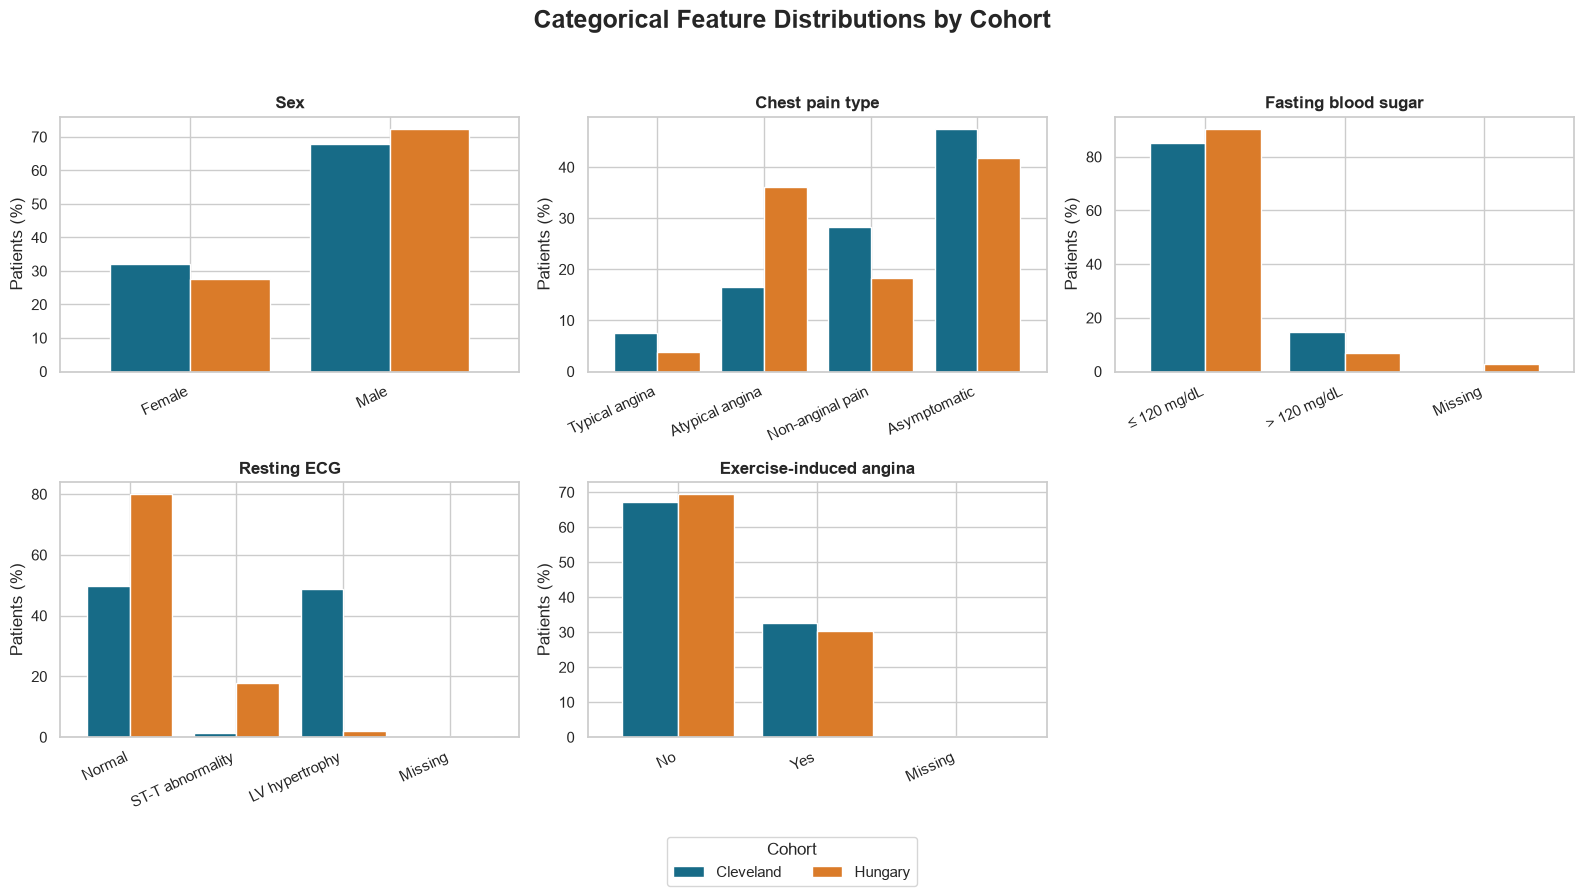

Figure saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\figures\categorical_feature_distributions.png


In [9]:
CATEGORY_LABELS = {
    "sex": {
        0: "Female",
        1: "Male",
    },
    "chest_pain_type": {
        1: "Typical angina",
        2: "Atypical angina",
        3: "Non-anginal pain",
        4: "Asymptomatic",
    },
    "fasting_blood_sugar": {
        0: "≤ 120 mg/dL",
        1: "> 120 mg/dL",
    },
    "resting_ecg": {
        0: "Normal",
        1: "ST-T abnormality",
        2: "LV hypertrophy",
    },
    "exercise_induced_angina": {
        0: "No",
        1: "Yes",
    },
}

FEATURE_TITLES = {
    "sex": "Sex",
    "chest_pain_type": "Chest pain type",
    "fasting_blood_sugar": "Fasting blood sugar",
    "resting_ecg": "Resting ECG",
    "exercise_induced_angina": "Exercise-induced angina",
}

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

legend_handles = None
legend_labels = None

for ax, feature in zip(axes, CATEGORICAL_FEATURES):
    plot_data = heart_data[["cohort", feature]].copy()

    plot_data["category"] = (
        plot_data[feature]
        .map(CATEGORY_LABELS[feature])
        .fillna("Missing")
    )

    category_order = list(CATEGORY_LABELS[feature].values())

    if plot_data["category"].eq("Missing").any():
        category_order.append("Missing")

    proportions = (
        pd.crosstab(
            plot_data["category"],
            plot_data["cohort"],
            normalize="columns",
        )
        .reindex(
            index=category_order,
            columns=["Cleveland", "Hungary"],
            fill_value=0,
        )
        .mul(100)
    )

    proportions.plot(
        kind="bar",
        ax=ax,
        color=["#176B87", "#DA7B29"],
        width=0.8,
    )

    ax.set_title(FEATURE_TITLES[feature], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Patients (%)")
    ax.tick_params(axis="x", rotation=25)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.get_legend().remove()

axes[-1].axis("off")

fig.suptitle(
    "Categorical Feature Distributions by Cohort",
    fontsize=18,
    fontweight="bold",
)

fig.legend(
    legend_handles,
    legend_labels,
    title="Cohort",
    loc="lower center",
    ncol=2,
)

fig.tight_layout(rect=[0, 0.07, 1, 0.95])

figure_path = FIGURE_DIR / "categorical_feature_distributions.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

Resting ECG showed the largest categorical distribution difference. Left ventricular hypertrophy was frequently recorded in Cleveland but was almost absent in Hungary, where normal ECG results predominated. Chest-pain categories also differed, particularly the frequency of atypical angina and non-anginal pain.

Sex and exercise-induced angina were more similarly distributed. The source data cannot distinguish whether these differences arose from patient populations, clinical measurement, coding practices or other collection procedures.

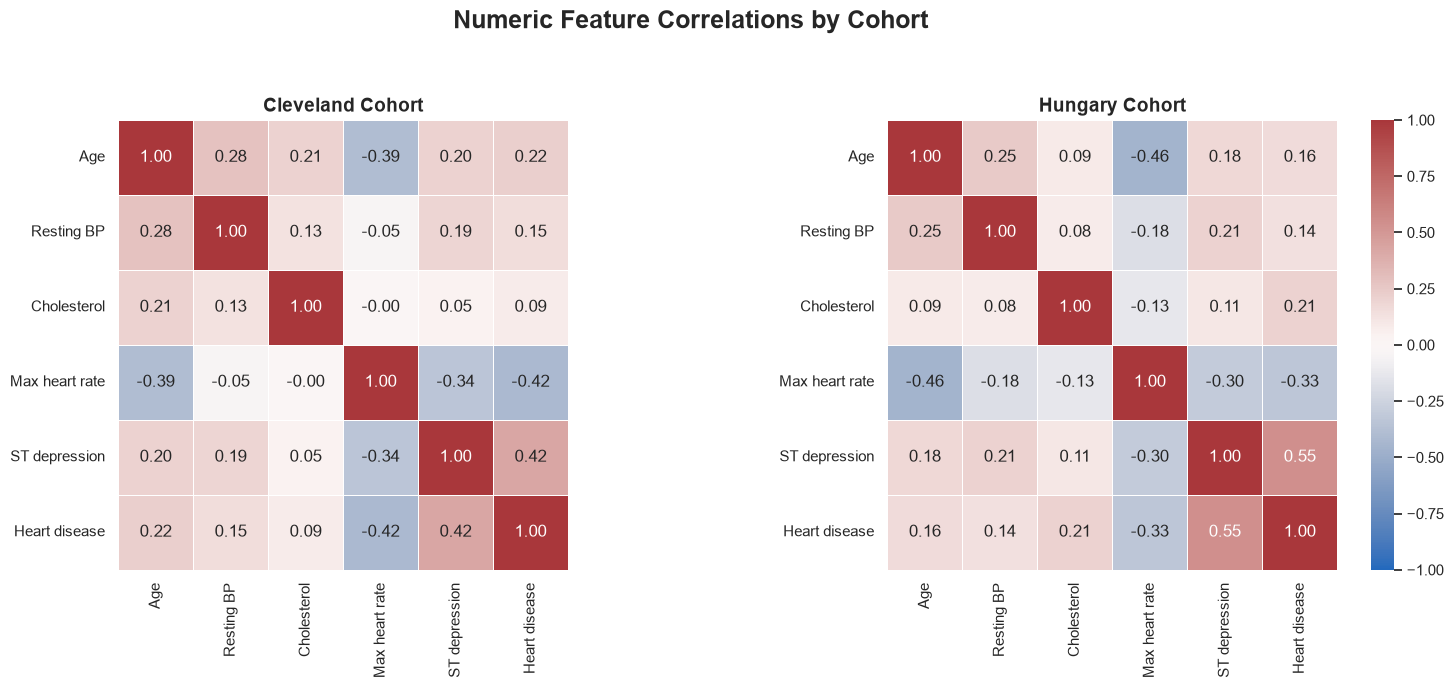

Figure saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\figures\numeric_correlations_by_cohort.png


In [10]:
CORRELATION_LABELS = {
    "age": "Age",
    "resting_blood_pressure": "Resting BP",
    "serum_cholesterol": "Cholesterol",
    "max_heart_rate": "Max heart rate",
    "st_depression": "ST depression",
    "heart_disease": "Heart disease",
}

correlation_features = NUMERIC_FEATURES + ["heart_disease"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for index, cohort_name in enumerate(["Cleveland", "Hungary"]):
    cohort_data = heart_data.loc[
        heart_data["cohort"] == cohort_name,
        correlation_features,
    ].rename(columns=CORRELATION_LABELS)

    correlation_matrix = cohort_data.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        ax=axes[index],
        cbar=index == 1,
    )

    axes[index].set_title(
        f"{cohort_name} Cohort",
        fontsize=14,
        fontweight="bold",
    )

fig.suptitle(
    "Numeric Feature Correlations by Cohort",
    fontsize=18,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

correlation_path = FIGURE_DIR / "numeric_correlations_by_cohort.png"
fig.savefig(correlation_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {correlation_path}")

The direction of the main numeric relationships was broadly consistent across cohorts. Recorded heart disease was positively correlated with ST depression and negatively correlated with maximum heart rate in both populations.

However, the strength of these relationships differed. ST depression had a stronger association with disease in Hungary, while maximum heart rate had a stronger negative association in Cleveland. Cholesterol also showed a stronger association with disease in Hungary.

These correlations are unadjusted descriptive relationships. They do not measure causation or show how the variables will behave when considered together by a model.

## 4. Modelling design

Cleveland is used as the first development cohort. A stratified 75/25 split reserves part of Cleveland for within-cohort testing while preserving the outcome balance.

The model is fitted using only the Cleveland training partition. The held-out Cleveland partition and the complete Hungarian cohort remain unseen during training. Comparing performance on these two test populations provides the first assessment of cross-cohort generalisation.

All missing-value replacement, numeric scaling and categorical encoding are contained inside the modelling pipeline and learned from training data only. This prevents information from the evaluation data leaking into model development.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [12]:
cleveland_model_data = heart_data.loc[
    heart_data["cohort"] == "Cleveland"
].copy()

hungary_model_data = heart_data.loc[
    heart_data["cohort"] == "Hungary"
].copy()

X_cleveland = cleveland_model_data[MODEL_FEATURES]
y_cleveland = cleveland_model_data["heart_disease"]

X_hungary = hungary_model_data[MODEL_FEATURES]
y_hungary = hungary_model_data["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleveland,
    y_cleveland,
    test_size=0.25,
    stratify=y_cleveland,
    random_state=RANDOM_STATE,
)

print(f"Cleveland training patients: {len(X_train)}")
print(f"Cleveland held-out patients: {len(X_test)}")
print(f"Hungarian external patients: {len(X_hungary)}")
print(f"Training prevalence: {y_train.mean():.1%}")
print(f"Held-out prevalence: {y_test.mean():.1%}")
print(f"External prevalence: {y_hungary.mean():.1%}")

Cleveland training patients: 227
Cleveland held-out patients: 76
Hungarian external patients: 294
Training prevalence: 45.8%
Held-out prevalence: 46.1%
External prevalence: 36.1%


In [13]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training complete")

Logistic Regression training complete


## 5. Initial Logistic Regression evaluation

The fitted model is evaluated on the held-out Cleveland patients and the external Hungarian cohort.

ROC-AUC and precision-recall AUC assess ranking performance across probability thresholds. Accuracy, sensitivity and specificity use a classification threshold of 0.50. The Brier score measures probability error, with lower values indicating better probabilistic predictions.

In [14]:
from sklearn.metrics import (
    accuracy_score,
    auc,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

In [15]:
def evaluate_classifier(
    model,
    X_evaluation,
    y_true,
    model_name,
    test_cohort,
    evaluation_type,
):
    probabilities = model.predict_proba(X_evaluation)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    precision_values, recall_values, _ = precision_recall_curve(
        y_true,
        probabilities,
    )

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return {
        "model": model_name,
        "test_cohort": test_cohort,
        "evaluation_type": evaluation_type,
        "patients": len(y_true),
        "prevalence": y_true.mean(),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": auc(recall_values, precision_values),
        "accuracy": accuracy_score(y_true, predictions),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "brier_score": brier_score_loss(y_true, probabilities),
    }

In [16]:
cleveland_result = evaluate_classifier(
    model=logistic_model,
    X_evaluation=X_test,
    y_true=y_test,
    model_name="Logistic Regression",
    test_cohort="Cleveland",
    evaluation_type="Within-cohort",
)

hungary_result = evaluate_classifier(
    model=logistic_model,
    X_evaluation=X_hungary,
    y_true=y_hungary,
    model_name="Logistic Regression",
    test_cohort="Hungary",
    evaluation_type="Cross-cohort",
)

initial_results = pd.DataFrame(
    [cleveland_result, hungary_result]
)

display(
    initial_results.set_index("test_cohort").round(3)
)

,model,evaluation_type,patients,prevalence,roc_auc,pr_auc,accuracy,sensitivity,specificity,brier_score
test_cohort,,,,,,,,,,
Cleveland,Logistic Regression,Within-cohort,76,0.461,0.925,0.905,0.816,0.743,0.878,0.115
Hungary,Logistic Regression,Cross-cohort,294,0.361,0.874,0.832,0.837,0.764,0.878,0.132


The Cleveland-trained Logistic Regression model retained strong discrimination in the Hungarian cohort, but both ROC-AUC and precision-recall AUC declined. The Brier score also increased, indicating less accurate probability estimates externally.

Accuracy was slightly higher in Hungary despite the decline in ranking performance. This illustrates why accuracy should not be interpreted alone: the Hungarian cohort had lower disease prevalence, changing the balance of positive and negative cases.

Sensitivity and specificity remained comparatively stable at the 0.50 classification threshold. Overall, the first result suggests measurable but not catastrophic performance shift.

In [17]:
from sklearn.base import clone

cleveland_result["train_cohort"] = "Cleveland"
hungary_result["train_cohort"] = "Cleveland"

X_hungary_train, X_hungary_test, y_hungary_train, y_hungary_test = (
    train_test_split(
        X_hungary,
        y_hungary,
        test_size=0.25,
        stratify=y_hungary,
        random_state=RANDOM_STATE,
    )
)

logistic_hungary_model = clone(logistic_model)
logistic_hungary_model.fit(X_hungary_train, y_hungary_train)

hungary_within_result = evaluate_classifier(
    model=logistic_hungary_model,
    X_evaluation=X_hungary_test,
    y_true=y_hungary_test,
    model_name="Logistic Regression",
    test_cohort="Hungary",
    evaluation_type="Within-cohort",
)

cleveland_external_result = evaluate_classifier(
    model=logistic_hungary_model,
    X_evaluation=X_cleveland,
    y_true=y_cleveland,
    model_name="Logistic Regression",
    test_cohort="Cleveland",
    evaluation_type="Cross-cohort",
)

hungary_within_result["train_cohort"] = "Hungary"
cleveland_external_result["train_cohort"] = "Hungary"

logistic_results = pd.DataFrame(
    [
        cleveland_result,
        hungary_result,
        hungary_within_result,
        cleveland_external_result,
    ]
)

result_columns = [
    "train_cohort",
    "test_cohort",
    "evaluation_type",
    "patients",
    "prevalence",
    "roc_auc",
    "pr_auc",
    "accuracy",
    "sensitivity",
    "specificity",
    "brier_score",
]

display(
    logistic_results[result_columns]
    .set_index(["train_cohort", "test_cohort"])
    .round(3)
)

evaluation_type  patients  prevalence  roc_auc  \
train_cohort test_cohort                                                  
Cleveland    Cleveland     Within-cohort        76       0.461    0.925   
             Hungary        Cross-cohort       294       0.361    0.874   
Hungary      Hungary       Within-cohort        74       0.365    0.924   
             Cleveland      Cross-cohort       303       0.459    0.843   

                          pr_auc  accuracy  sensitivity  specificity  \
train_cohort test_cohort                                               
Cleveland    Cleveland     0.905     0.816        0.743        0.878   
             Hungary       0.832     0.837        0.764        0.878   
Hungary      Hungary       0.867     0.851        0.778        0.894   
             Cleveland     0.836     0.756        0.712        0.793   

                          brier_score  
train_cohort test_cohort               
Cleveland    Cleveland          0.115  
             Hungary            0.132  
Hungary      Hungary            0.107  
             Cleveland          0.163

Cross-cohort performance was asymmetric. The Hungary-trained model experienced a larger external decline when evaluated in Cleveland than the Cleveland-trained model experienced when evaluated in Hungary.

The Hungary-to-Cleveland direction showed deterioration in discrimination, accuracy, sensitivity, specificity and probability error. This suggests that successful transfer in one direction does not guarantee equally reliable transfer in the reverse direction.

The within-cohort test sets are relatively small, so these point estimates contain uncertainty. Later sensitivity analysis will assess whether the main pattern persists across different data splits.

## 6. Random Forest comparison

Random Forest is evaluated as a nonlinear comparison model. It can represent interactions and more complex feature relationships than Logistic Regression, but may be more prone to overfitting on small datasets.

Both models use the same patient splits, preprocessing rules and evaluation metrics to support a fair comparison.

In [18]:
from sklearn.ensemble import RandomForestClassifier

random_forest_template = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_cleveland = clone(random_forest_template)
random_forest_cleveland.fit(X_train, y_train)

random_forest_hungary = clone(random_forest_template)
random_forest_hungary.fit(X_hungary_train, y_hungary_train)

rf_cleveland_within = evaluate_classifier(
    random_forest_cleveland,
    X_test,
    y_test,
    "Random Forest",
    "Cleveland",
    "Within-cohort",
)
rf_cleveland_within["train_cohort"] = "Cleveland"

rf_hungary_external = evaluate_classifier(
    random_forest_cleveland,
    X_hungary,
    y_hungary,
    "Random Forest",
    "Hungary",
    "Cross-cohort",
)
rf_hungary_external["train_cohort"] = "Cleveland"

rf_hungary_within = evaluate_classifier(
    random_forest_hungary,
    X_hungary_test,
    y_hungary_test,
    "Random Forest",
    "Hungary",
    "Within-cohort",
)
rf_hungary_within["train_cohort"] = "Hungary"

rf_cleveland_external = evaluate_classifier(
    random_forest_hungary,
    X_cleveland,
    y_cleveland,
    "Random Forest",
    "Cleveland",
    "Cross-cohort",
)
rf_cleveland_external["train_cohort"] = "Hungary"

random_forest_results = pd.DataFrame(
    [
        rf_cleveland_within,
        rf_hungary_external,
        rf_hungary_within,
        rf_cleveland_external,
    ]
)

all_model_results = pd.concat(
    [logistic_results, random_forest_results],
    ignore_index=True,
)

display(
    all_model_results[
        ["model"] + result_columns
    ]
    .set_index(["model", "train_cohort", "test_cohort"])
    .round(3)
)

evaluation_type  patients  \
model               train_cohort test_cohort                             
Logistic Regression Cleveland    Cleveland     Within-cohort        76   
                                 Hungary        Cross-cohort       294   
                    Hungary      Hungary       Within-cohort        74   
                                 Cleveland      Cross-cohort       303   
Random Forest       Cleveland    Cleveland     Within-cohort        76   
                                 Hungary        Cross-cohort       294   
                    Hungary      Hungary       Within-cohort        74   
                                 Cleveland      Cross-cohort       303   

                                              prevalence  roc_auc  pr_auc  \
model               train_cohort test_cohort                                
Logistic Regression Cleveland    Cleveland         0.461    0.925   0.905   
                                 Hungary           0.361    0.874   0.832   
                    Hungary      Hungary           0.365    0.924   0.867   
                                 Cleveland         0.459    0.843   0.836   
Random Forest       Cleveland    Cleveland         0.461    0.913   0.892   
                                 Hungary           0.361    0.890   0.838   
                    Hungary      Hungary           0.365    0.934   0.892   
                                 Cleveland         0.459    0.866   0.870   

                                              accuracy  sensitivity  \
model               train_cohort test_cohort                          
Logistic Regression Cleveland    Cleveland       0.816        0.743   
                                 Hungary         0.837        0.764   
                    Hungary      Hungary         0.851        0.778   
                                 Cleveland       0.756        0.712   
Random Forest       Cleveland    Cleveland       0.855        0.829   
                                 Hungary         0.830        0.755   
                    Hungary      Hungary         0.851        0.778   
                                 Cleveland       0.785        0.640   

                                              specificity  brier_score  
model               train_cohort test_cohort                            
Logistic Regression Cleveland    Cleveland          0.878        0.115  
                                 Hungary            0.878        0.132  
                    Hungary      Hungary            0.894        0.107  
                                 Cleveland          0.793        0.163  
Random Forest       Cleveland    Cleveland          0.878        0.128  
                                 Hungary            0.872        0.129  
                    Hungary      Hungary            0.894        0.103  
                                 Cleveland          0.909        0.155

Random Forest produced somewhat stronger cross-cohort discrimination and probability scores than Logistic Regression. However, performance depended on the metric and transfer direction.

In the Hungary-to-Cleveland evaluation, Random Forest achieved higher ROC-AUC, precision-recall AUC and specificity, but lower sensitivity. At the 0.50 threshold, it therefore missed a larger proportion of patients with recorded disease while producing fewer false positives.

The results do not support selecting one model from accuracy alone. Model choice would depend on the relative consequences of false negatives and false positives, which cannot be determined from this educational dataset.

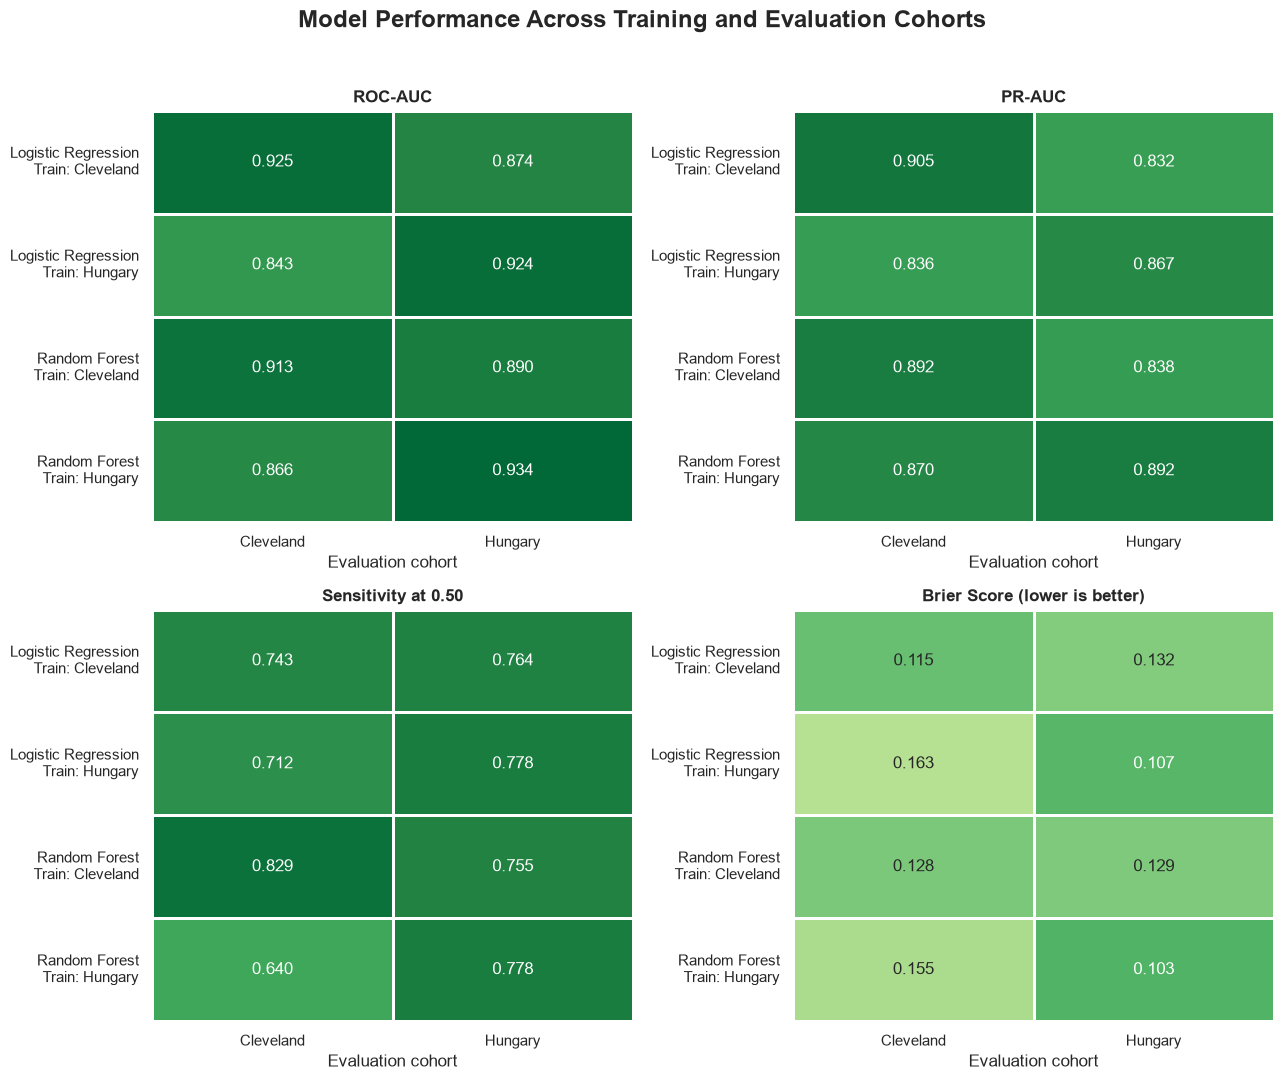

Metrics saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\metrics\model_performance.csv
Figure saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\figures\model_performance_heatmaps.png


In [19]:
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = METRICS_DIR / "model_performance.csv"
all_model_results[result_columns + ["model"]].to_csv(
    metrics_path,
    index=False,
)

heatmap_data = all_model_results.copy()

heatmap_data["model_training"] = (
    heatmap_data["model"]
    + "\nTrain: "
    + heatmap_data["train_cohort"]
)

row_order = [
    "Logistic Regression\nTrain: Cleveland",
    "Logistic Regression\nTrain: Hungary",
    "Random Forest\nTrain: Cleveland",
    "Random Forest\nTrain: Hungary",
]

metric_settings = {
    "roc_auc": {
        "title": "ROC-AUC",
        "vmin": 0.5,
        "vmax": 1.0,
        "cmap": "YlGn",
    },
    "pr_auc": {
        "title": "PR-AUC",
        "vmin": 0.5,
        "vmax": 1.0,
        "cmap": "YlGn",
    },
    "sensitivity": {
        "title": "Sensitivity at 0.50",
        "vmin": 0.0,
        "vmax": 1.0,
        "cmap": "YlGn",
    },
    "brier_score": {
        "title": "Brier Score (lower is better)",
        "vmin": 0.0,
        "vmax": 0.25,
        "cmap": "YlGn_r",
    },
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (metric, settings) in zip(axes, metric_settings.items()):
    metric_matrix = (
        heatmap_data.pivot(
            index="model_training",
            columns="test_cohort",
            values=metric,
        )
        .reindex(
            index=row_order,
            columns=["Cleveland", "Hungary"],
        )
    )

    sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".3f",
        cmap=settings["cmap"],
        vmin=settings["vmin"],
        vmax=settings["vmax"],
        linewidths=1,
        ax=ax,
        cbar=False,
    )

    ax.set_title(settings["title"], fontweight="bold")
    ax.set_xlabel("Evaluation cohort")
    ax.set_ylabel("")

fig.suptitle(
    "Model Performance Across Training and Evaluation Cohorts",
    fontsize=17,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

performance_heatmap_path = (
    FIGURE_DIR / "model_performance_heatmaps.png"
)

fig.savefig(
    performance_heatmap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Metrics saved to: {metrics_path}")
print(f"Figure saved to: {performance_heatmap_path}")

The performance heatmaps show that both models retained useful discrimination across cohorts, but external performance generally fell relative to within-cohort evaluation.

Random Forest achieved the strongest cross-cohort ROC-AUC in both transfer directions. However, its Hungary-to-Cleveland sensitivity declined to 0.640 at the 0.50 threshold, demonstrating that stronger overall ranking performance does not guarantee better identification of positive cases at a particular decision threshold.

The clearest probability deterioration occurred when models trained in Hungary were evaluated in Cleveland. This direction produced higher Brier scores for both models, reinforcing the conclusion that model transfer was asymmetric.